# DS10 · Linear algebra: rank, projection, and identifiability

<!-- paper-first -->
### Research question

**Reading:** [PD03](../../curriculum/papers/design.md#pd03). Review the assigned figure or result before starting the lesson.

**Question:** Could redundant predictors prevent a unique explanation of measured variation?

Record a prediction, a source location, and one point you want this lesson to clarify. Ask your AI tutor to distinguish the paper’s evidence from its interpretation.
<!-- /paper-first -->

<!-- key-references -->
### Why this technique matters

Neuroimaging GLMs (SPM, FSL FEAT, AFNI 3dDeconvolve, nilearn) routinely encounter rank-deficient or nearly collinear design matrices from overspecified dummy variables, multi-site covariates, or rapid event-related trials convolved with the sluggish hemodynamic response. Understanding column-space projection P = X X+, the rank-nullity theorem, and the contrast estimability condition c in R(X^T) explains why fitted predictions y_hat are invariant to the generalized inverse even when individual beta_hat coordinates are non-unique, and why collinear regressors inflate contrast variance Var(c^T beta_hat) = sigma^2 c^T (X^T X)^-1 c and collapse test-retest reliability (Smith et al., 2007; Prince et al., 2022).

**Key references** · *Linear algebra of the General Linear Model: column space projection, rank deficiency, contrast estimability, and Moore-Penrose pseudoinverse*

- *Foundational* — Penrose (1955), [A generalized inverse for matrices](https://doi.org/10.1017/s0305004100030401), *Mathematical Proceedings of the Cambridge Philosophical Society*. Establishes the existence and uniqueness of the Moore-Penrose pseudoinverse X+ via the four Penrose conditions, providing the minimum-norm least-squares solution for rank-deficient design matrices.
- *Foundational* — Smith et al. (2007), [Meaningful design and contrast estimability in FMRI](https://doi.org/10.1016/j.neuroimage.2006.09.019), *NeuroImage*. Defines meaningful contrast specification, estimability, and design efficiency (1 / c^T (X^T X)^-1 c) for fMRI general linear models.
- *State of the art* — Prince et al. (2022), [Improving the accuracy of single-trial fMRI response estimates using GLMsingle](https://doi.org/10.7554/eLife.77599), *eLife*. Introduces GLMsingle to stabilize single-trial fMRI beta estimates under severe hemodynamic collinearity using library HRFs, GLMdenoise, and fractional ridge regression.
- *Critical evaluation* — Mumford et al. (2015), [Orthogonalization of Regressors in fMRI Models](https://doi.org/10.1371/journal.pone.0126255), *PLOS ONE*. Shows how collinearity operates in fMRI design matrices and why sequential regressor orthogonalization alters parameter interpretation without changing the overall subspace projection.

Full entries, verification status and citation counts: [course bibliography](../../curriculum/papers/REFERENCES.md#ds10).
<!-- /key-references -->

**Format:** 75–100 minutes of guided work, plus 30–60 minutes in the assigned existing course material. **Prerequisite:** the foundations notebooks; follow this strand in order. The core exercise is synthetic, offline, and independently runnable. It demonstrates mechanics, not a validated participant-data analysis.

## Existing course material

Read [Neuromatch W1D4 Tutorial1: Geometric view of data](https://github.com/NeuromatchAcademy/course-content/blob/44634e960df7a14cd0bf7398187f2d209d26b0e8/tutorials/W1D4_DimensionalityReduction/W1D4_Tutorial1.ipynb). Use the indicated topic, then return here to apply it to a neuroimaging question. Berkeley material is linked in its original form, not adapted or redistributed; its CC BY-NC-ND terms remain upstream. Neuromatch material is CC BY 4.0 with separately licensed software; selected unmodified copies live in `third_party/data_science`. The explanation and dataset below are original.

## Understand the transformation

### 1. Motivation from the Assigned Papers: Why Collinear Task Regressors Undermine Individual-Difference Reliability

Every General Linear Model (GLM) in task fMRI or morphometry expresses an observed time series or cohort phenotype $y \in \mathbb{R}^N$ as a linear combination of design columns $X \beta + \epsilon$, where $X \in \mathbb{R}^{N \times p}$. A profound distinction separates the **projected fitted signal $\hat{y} = X\hat{\beta}$** (which lives in the column space $\mathcal{C}(X)$ and is always unique) from the **individual regression weights $\hat{\beta} \in \mathbb{R}^p$** (which become unstable or non-unique when columns of $X$ are nearly collinear):

- **Elliott et al. (2020), *What Is the Test-Retest Reliability of Common Task-Functional MRI Measures? New Empirical Evidence and a Meta-Analysis* (`PD03`, Abstract, Figures 3–4, Discussion on Experimental vs Individual-Difference Research, and Appendix on ICC):** Elliott et al. demonstrated that common task-fMRI difference contrasts ($c^\top \hat{\beta} = \hat{\beta}_{\text{task}} - \hat{\beta}_{\text{control}}$) often exhibit poor test-retest reliability ($\text{ICC} < 0.40$) across sessions. A major linear-algebraic driver of within-session $\hat{\beta}$ instability in rapid event-related designs is **hemodynamic collinearity**: when cue, delay, and probe events occur within $1\text{–}2\text{ seconds}$ of one another, convolving their stick functions with the sluggish canonical HRF ($\sim 6\text{ s}$ peak) produces highly overlapping, nearly collinear columns in $X$. While the overall fitted BOLD waveform $\hat{y} = P y$ is completely stable, the variance of individual parameter estimates $\text{Var}(\hat{\beta}_j) = \sigma^2 [(X^\top X)^{-1}]_{jj}$ explodes as the condition number $\kappa(X) = \sigma_{\max}(X)/\sigma_{\min}(X) \to \infty$!

### 2. Relation to Graduate Courses and Upstream Modules

This lesson synthesizes **Neuromatch Academy W1D4 Tutorial 1 (Geometric View of Data & Subspace Projections)** and **UC Berkeley Data 100 (Ordinary Least Squares Geometry, Orthogonal Projections, and Rank Deficiency)** with **USC NIIN 540/580 (GLM Design Efficiency & Contrast Identifiability)** and **Stanford Psych 204B**. We derive the properties of the orthogonal projection matrix $P = X(X^\top X)^+ X^\top$, prove why $\hat{y}$ is invariant to null-space perturbations $\beta + v$ ($v \in \mathcal{N}(X)$), and connect the singular value spectrum of $X$ directly to contrast variance $\sigma^2 c^\top (X^\top X)^+ c$.

### 3. Mathematical Formulation: Column Space, Projection Idempotence, Null Space, and Condition Number

Let $X \in \mathbb{R}^{N \times p}$ be a design matrix with column space $\mathcal{C}(X) = \{X\beta : \beta \in \mathbb{R}^p\} \subseteq \mathbb{R}^N$, null space $\mathcal{N}(X) = \{v \in \mathbb{R}^p : X v = 0\} \subseteq \mathbb{R}^p$, and rank $r = \text{rank}(X) = \dim \mathcal{C}(X) \le \min(N, p)$.

#### A. Orthogonal Projection Matrix $P$ and Residual Annihilator $M = I - P$
Minimizing the Euclidean residual norm $\|y - X\beta\|_2^2$ projects $y$ orthogonally onto $\mathcal{C}(X)$. Using the Moore-Penrose pseudoinverse $X^+ = (X^\top X)^+ X^\top$, the **orthogonal projection matrix** $P \in \mathbb{R}^{N \times N}$ is:
$$P = X X^+ = X (X^\top X)^+ X^\top, \qquad \hat{y} = P y, \qquad e = y - \hat{y} = (I_N - P) y = M y$$
Regardless of whether $X$ has full column rank ($r = p$) or is rank-deficient ($r < p$), $P$ and $M = I_N - P$ satisfy four fundamental geometric invariants:
1. **Symmetry:** $P^\top = P$ and $M^\top = M$.
2. **Idempotence:** $P^2 = P$ and $M^2 = M$ (projecting an already-projected vector changes nothing: $P\hat{y} = \hat{y}$).
3. **Orthogonality of Fit and Residual:** $P M = 0 \implies \hat{y}^\top e = (Py)^\top (My) = y^\top P^\top M y = 0$, which yields the exact Pythagorean decomposition $\|y\|_2^2 = \|\hat{y}\|_2^2 + \|e\|_2^2$.
4. **Trace Equals Subspace Dimension:** $\text{tr}(P) = \text{rank}(X) = r$, and $\text{tr}(M) = N - r$ (the exact residual degrees of freedom!).

#### B. Non-Identifiability Along the Null Space $\mathcal{N}(X)$
By the Rank-Nullity Theorem, $\dim \mathcal{N}(X) = p - r$. When $r < p$ (for instance, when a constant column $\mathbf{1}$ equals the sum of Exhaustive Condition Dummies $x_{\text{task}} + x_{\text{rest}} = \mathbf{1}$, or when two regressors are exact duplicates), $\mathcal{N}(X)$ is non-trivial. Let $\hat{\beta}_{\text{min}} = X^+ y$ be the unique minimum-norm least-squares solution ($\|\hat{\beta}_{\text{min}}\|_2$ minimal). Then **every vector** in the affine subspace:
$$\mathcal{S}_{\text{LS}} = \left\{ \hat{\beta}_{\text{min}} + v \;:\; v \in \mathcal{N}(X) \right\}$$
achieves the **exact same predicted signal $\hat{y}$ and residual sum of squares**:
$$X(\hat{\beta}_{\text{min}} + v) = X\hat{\beta}_{\text{min}} + \underbrace{Xv}_{0} = \hat{y}$$
A linear contrast $c^\top \beta$ is **estimable (identifiable)** if and only if $c \perp \mathcal{N}(X)$ (equivalently, $c \in \mathcal{R}(X^\top)$), in which case $c^\top(\hat{\beta}_{\text{min}} + v) = c^\top \hat{\beta}_{\text{min}}$ is invariant to $v$!

#### C. Near-Collinearity, Condition Number $\kappa(X)$, and Contrast Variance Inflation (`PD03`)
Let $X = U \Sigma V^\top = \sum_{j=1}^r \sigma_j u_j v_j^\top$ be the thin Singular Value Decomposition of a full-rank design ($r = p$) with singular values $\sigma_1 \ge \sigma_2 \ge \dots \ge \sigma_p > 0$. The **condition number** is $\kappa(X) = \sigma_1 / \sigma_p$. Under homoscedastic noise $\epsilon \sim (0, \sigma_\epsilon^2 I_N)$, the covariance matrix of $\hat{\beta}$ is:
$$\text{Cov}(\hat{\beta}) = \sigma_\epsilon^2 (X^\top X)^{-1} = \sigma_\epsilon^2 \sum_{j=1}^p \frac{1}{\sigma_j^2} v_j v_j^\top, \qquad \text{tr}\,\text{Cov}(\hat{\beta}) = \sigma_\epsilon^2 \sum_{j=1}^p \frac{1}{\sigma_j^2}$$
When two task regressors $x_1, x_2$ have correlation $\rho_{12} \to 1$, the smallest singular value collapses as $\sigma_p \propto \sqrt{1 - \rho_{12}} \to 0$:
- The **difference contrast** $c_{\text{diff}} = (1, -1)^\top$ aligns with the trailing singular vector $v_p$, so its variance $\text{Var}(\hat{\beta}_1 - \hat{\beta}_2) \propto \frac{1}{1 - \rho_{12}} \to \infty$ explodes!
- The **sum contrast** $c_{\text{sum}} = (1, +1)^\top$ aligns with the leading singular vector $v_1$, so its variance $\text{Var}(\hat{\beta}_1 + \hat{\beta}_2) \propto \frac{1}{1 + \rho_{12}}$ remains completely stable!

### 4. Transformation & Bookkeeping Contract

| Linear Algebra Object | Mathematical Expression | Shape | Invariant Under Collinearity ($\rho_{12} \to 1$)? | Neuroimaging Interpretation (`PD03`) |
| :--- | :--- | :--- | :--- | :--- |
| **Projection Matrix** ($P$) | $X(X^\top X)^+ X^\top = U_r U_r^\top$ | $(N, N)$ | **YES** (depends only on $\mathcal{C}(X)$) | Maps raw time series $y$ to fitted BOLD $\hat{y}$ |
| **Subspace Dimension** | $\text{tr}(P) = \text{rank}(X) = r$ | Scalar | Drops from $p$ to $r$ at exact $\rho_{12}=1$ | Effective model degrees of freedom |
| **Fitted Signal** ($\hat{y}$) | $P y = X \hat{\beta}$ | $(N,)$ | **YES** ($\|X(\hat{\beta}+v) - \hat{y}\|_2 = 0$) | Predicted hemodynamic waveform |
| **Individual / Diff Weights** ($\hat{\beta}_1 - \hat{\beta}_2$) | $c_{\text{diff}}^\top (X^\top X)^+ X^\top y$ | Scalar | **NO ($\text{Var} \propto 1/(1-\rho_{12}) \to \infty$)** | Rapid cue-minus-delay contrast (`PD03` low ICC) |
| **Sum Contrast** ($\hat{\beta}_1 + \hat{\beta}_2$) | $c_{\text{sum}}^\top (X^\top X)^+ X^\top y$ | Scalar | **YES ($\text{Var} \propto 1/(1+\rho_{12})$)** | Combined cue-plus-delay activation |

## AI-guided prediction (Suggestive prompt for macOS Goose + Ollama: Qwen & Gemma)

Before running the code cells, predict the algebraic behavior and test an AI tutor with this prompt:

> Suppose an fMRI GLM design matrix $X \in \mathbb{R}^{100 \times 3}$ contains an intercept column $\mathbf{1}$, a `Task_ON` indicator $x_1 \in \{0, 1\}^{100}$, and a `Rest_OFF` indicator $x_2 = \mathbf{1} - x_1$.
> 1. What is $\text{rank}(X)$, what is $\text{tr}(P)$ for the projection matrix $P = X X^+$, and what is a basis vector $v$ for the null space $\mathcal{N}(X)$?
> 2. If `np.linalg.lstsq` returns a parameter vector $\hat{\beta}$, why can we add $+500 \cdot v$ to $\hat{\beta}$ without changing $\hat{y} = X\hat{\beta}$ by even $10^{-15}$?
> 3. In a rapid event-related design (`PD03`) where Cue ($x_1$) and Probe ($x_2$) HRF regressors have correlation $\rho_{12} = 0.98$, why is $\hat{\beta}_1 + \hat{\beta}_2$ highly reliable across sessions while $\hat{\beta}_1 - \hat{\beta}_2$ is wildly unstable?


### Part 1 · Core Mathematical Implementation: Orthogonal Projection Geometry & Exact Rank Deficiency

We first construct an over-parameterized fMRI block-design matrix $X \in \mathbb{R}^{80 \times 3}$ containing an intercept $\mathbf{1}$, a task regressor $x_{\text{task}}$, and an explicit rest regressor $x_{\text{rest}} = \mathbf{1} - x_{\text{task}}$ (a classic "dummy-variable trap" where Column 1 = Column 2 + Column 3, so $p = 3$ but $\text{rank}(X) = 2$). We compute $P = X X^+$, verify all four geometric projection theorems ($P^\top = P$, $P^2 = P$, $\hat{y}^\top e = 0$, $\text{tr}(P) = \text{rank}(X) = 2$), and construct the exact null-space vector $v = (1, -1, -1)^\top / \sqrt{3} \in \mathcal{N}(X)$.


In [1]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(1010)
N_tr = 80
intercept = np.ones(N_tr)
x_task = ((np.arange(N_tr) // 10) % 2 == 1).astype(float)
x_rest = 1.0 - x_task  # Exact linear dependence: intercept = x_task + x_rest!

X_rank_def = np.column_stack([intercept, x_task, x_rest])
y_bold = 800.0 * intercept + 16.0 * x_task + rng.normal(0.0, 3.0, size=N_tr)

# Compute Moore-Penrose pseudoinverse X^+ and orthogonal projection matrix P = X X^+
X_pinv = np.linalg.pinv(X_rank_def)
P_proj = X_rank_def @ X_pinv
M_annih = np.eye(N_tr) - P_proj

y_hat = P_proj @ y_bold
e_resid = M_annih @ y_bold
rank_X = int(np.linalg.matrix_rank(X_rank_def))
trace_P = float(np.trace(P_proj))

# Verify the 4 geometric projection invariants
assert rank_X == 2
assert np.isclose(trace_P, rank_X, atol=1e-12)
assert np.allclose(P_proj, P_proj.T, atol=1e-12)              # Symmetry: P^T = P
assert np.allclose(P_proj @ P_proj, P_proj, atol=1e-12)      # Idempotence: P^2 = P
cos_orth = float((y_hat @ e_resid) / (np.linalg.norm(y_hat) * np.linalg.norm(e_resid)))
assert np.isclose(cos_orth, 0.0, atol=1e-13)                  # Orthogonality: cos(y_hat, e) = 0
assert np.isclose(np.sum(y_bold**2), np.sum(y_hat**2) + np.sum(e_resid**2), rtol=1e-12)  # Pythagoras

# Extract explicit unit null-space vector v in N(X) via SVD right singular vector for sigma_3 = 0
U, sing_vals, Vt = np.linalg.svd(X_rank_def, full_matrices=False)
v_null = Vt[-1]  # Corresponding to singular value sigma_3 == 0
assert np.allclose(X_rank_def @ v_null, 0.0, atol=1e-12)

print(f"Design matrix X shape: {X_rank_def.shape} | Singular values: {sing_vals.round(4).tolist()}")
print(f"Matrix rank(X): {rank_X} | trace(P): {trace_P:.6f} | Residual df trace(I - P): {np.trace(M_annih):.1f}")
print(f"Null-space basis vector v (where X @ v = 0): {v_null.round(4).tolist()}")
print(f"Orthogonality check cos(y_hat, e): {cos_orth:.2e} | Pythagorean error: {abs(np.sum(y_bold**2) - (np.sum(y_hat**2)+np.sum(e_resid**2))):.2e}")


Design matrix X shape: (80, 3) | Singular values: [10.9545, 6.3246, 0.0]
Matrix rank(X): 2 | trace(P): 2.000000 | Residual df trace(I - P): 78.0
Null-space basis vector v (where X @ v = 0): [-0.5774, 0.5774, 0.5774]
Orthogonality check cos(y_hat, e): 5.89e-14 | Pythagorean error: 2.98e-08


### Part 2 · Deliberate Methodological / AI Failure Modes: Non-Identifiable $\hat{\beta}$ Interpretation & Estimable vs Non-Estimable Contrasts

When an analyst fits a rank-deficient or collinear GLM without checking $\text{rank}(X)$ or $\kappa(X)$, `np.linalg.lstsq` or `scipy.linalg.lstsq` returns the minimum-$L_2$-norm solution $\hat{\beta}_{\text{min}}$ without raising an error.
- **The Failure Mode:** Interpreting the individual coefficient $\hat{\beta}_2$ ("Task slope") or $\hat{\beta}_3$ ("Rest slope") as a unique biological parameter when in fact $\hat{\beta}(\alpha) = \hat{\beta}_{\text{min}} + \alpha v_{\text{null}}$ generates the **exact same predicted fMRI time series $\hat{y}$ for every $\alpha \in (-\infty, +\infty)$**!
- **The Verified Repair:** Testing whether a scientific contrast $c \in \mathbb{R}^p$ is **estimable** ($c^\top v_{\text{null}} = 0$, equivalently $c^\top X^+ X = c^\top$). Here, the difference contrast between Task and Rest corresponds to $(0, 1, -1)^\top$: let's check whether $(0, 1, -1)^\top$ is orthogonal to $v_{\text{null}} = \frac{1}{\sqrt{3}}(-1, 1, 1)^\top$! Indeed, $0(-1) + 1(1) + (-1)(1) = 0$, so $\beta_{\text{task}} - \beta_{\text{rest}}$ is **exactly invariant** to $\alpha$, whereas $\beta_{\text{task}}$ alone ($c = (0, 1, 0)^\top$) can be made arbitrarily positive or negative!


In [2]:
beta_min = X_pinv @ y_bold

# Generate infinitely many distinct parameter vectors beta(alpha) = beta_min + alpha * v_null
alphas = [-500.0, 0.0, +500.0]
c_non_estimable = np.array([0.0, 1.0, 0.0])       # Asks for beta_task alone (NOT orthogonal to v_null!)
c_estimable_diff = np.array([0.0, 1.0, -1.0])     # Asks for Task minus Rest (Orthogonal to v_null: c^T v_null = 0!)
c_estimable_task_abs = np.array([1.0, 1.0, 0.0])  # Asks for Intercept + beta_task = absolute Task mean!

print(f"Is c_non_estimable [0, 1, 0] orthogonal to v_null?   c @ v_null = {c_non_estimable @ v_null:+.4f} (NON-IDENTIFIABLE!)")
print(f"Is c_estimable_diff [0, 1, -1] orthogonal to v_null? c @ v_null = {c_estimable_diff @ v_null:+.4e} (IDENTIFIABLE!)")

ident_rows = []
for a in alphas:
    b_alpha = beta_min + a * v_null
    y_hat_alpha = X_rank_def @ b_alpha
    max_pred_diff = float(np.max(np.abs(y_hat_alpha - y_hat)))
    ident_rows.append({
        'alpha_shift': a,
        'beta_0_intercept': round(float(b_alpha[0]), 2),
        'beta_1_task_alone': round(float(c_non_estimable @ b_alpha), 2),
        'beta_2_rest_alone': round(float(b_alpha[2]), 2),
        'Contrast_Task_minus_Rest': round(float(c_estimable_diff @ b_alpha), 4),
        'Contrast_Abs_Task_Mean': round(float(c_estimable_task_abs @ b_alpha), 4),
        'Max_|X*beta - y_hat|': f"{max_pred_diff:.2e}",
    })

ident_df = pd.DataFrame(ident_rows)
print("\n--- Parameter Non-Identifiability vs Estimable Contrast Invariance ---")
print(ident_df.to_string(index=False))

assert np.allclose(ident_df['Contrast_Task_minus_Rest'], ident_df['Contrast_Task_minus_Rest'].iloc[0], atol=1e-10)
assert ident_df['beta_1_task_alone'].max() - ident_df['beta_1_task_alone'].min() > 500.0


Is c_non_estimable [0, 1, 0] orthogonal to v_null?   c @ v_null = +0.5774 (NON-IDENTIFIABLE!)
Is c_estimable_diff [0, 1, -1] orthogonal to v_null? c @ v_null = +1.1102e-16 (IDENTIFIABLE!)

--- Parameter Non-Identifiability vs Estimable Contrast Invariance ---
 alpha_shift  beta_0_intercept  beta_1_task_alone  beta_2_rest_alone  Contrast_Task_minus_Rest  Contrast_Abs_Task_Mean Max_|X*beta - y_hat|
      -500.0            827.14             -11.30             -27.58                   16.2803                815.8427             2.27e-13
         0.0            538.47             277.37             261.09                   16.2803                815.8427             2.27e-13
       500.0            249.79             566.05             549.77                   16.2803                815.8427             2.27e-13


### Part 3 · Collinearity & Test-Retest Reliability Sweep (`PD03` Elliott et al., 2020)

In rapid event-related fMRI (`PD03`), two task regressors $x_1$ (`Cue`) and $x_2$ (`Probe`) separated by a short delay are full-rank ($r = 2$), but their correlation $\rho_{12} = \text{Corr}(x_1, x_2)$ approaches $1$ as the inter-stimulus interval shrinks. We sweep $\rho_{12} \in [0.00, 0.995]$ and track:
1. The condition number $\kappa(X) = \sigma_{\max}(X) / \sigma_{\min}(X)$,
2. The variance of the difference contrast $\text{Var}(\hat{\beta}_1 - \hat{\beta}_2)$ vs the sum contrast $\text{Var}(\hat{\beta}_1 + \hat{\beta}_2)$, and
3. The resulting two-session **Test-Retest Reliability ($\text{ICC}$)** of individual differences in $\hat{\beta}_1 - \hat{\beta}_2$ (`PD03`).


In [3]:
rho_grid = np.array([0.0, 0.30, 0.60, 0.80, 0.90, 0.95, 0.98, 0.995])
N_time = 120
sigma_eps = 1.0
true_between_subj_var = 0.25  # True biological individual-difference variance in contrast

z1 = rng.normal(0.0, 1.0, size=N_time)
z1 = (z1 - z1.mean()) / z1.std(ddof=0)
z2_orth = rng.normal(0.0, 1.0, size=N_time)
z2_orth = z2_orth - (z2_orth @ z1) / (z1 @ z1) * z1
z2_orth = (z2_orth - z2_orth.mean()) / z2_orth.std(ddof=0)

collin_records = []
c_diff_2d = np.array([1.0, -1.0])
c_sum_2d = np.array([1.0, +1.0])

for rho in rho_grid:
    x1 = z1
    x2 = rho * z1 + np.sqrt(1.0 - rho**2) * z2_orth
    X_2 = np.column_stack([x1, x2])
    svals = np.linalg.svd(X_2, compute_uv=False)
    cond_num = float(svals[0] / svals[1])
    cov_beta = (sigma_eps ** 2) * np.linalg.inv(X_2.T @ X_2)

    var_diff = float(c_diff_2d @ cov_beta @ c_diff_2d)
    var_sum = float(c_sum_2d @ cov_beta @ c_sum_2d)
    # Elliott et al. (PD03) Test-Retest ICC = Var_between / (Var_between + Var_within_estimation_error)
    icc_diff = true_between_subj_var / (true_between_subj_var + var_diff)
    icc_sum = true_between_subj_var / (true_between_subj_var + var_sum)

    collin_records.append({
        'Regressor_Corr_rho': rho,
        'Condition_Number_kappa': round(cond_num, 2),
        'Var_Diff_(b1-b2)': round(var_diff, 4),
        'Var_Sum_(b1+b2)': round(var_sum, 4),
        'Retest_ICC_Diff': round(icc_diff, 3),
        'Retest_ICC_Sum': round(icc_sum, 3),
    })

collin_df = pd.DataFrame(collin_records)
print(collin_df.to_string(index=False))

assert collin_df.iloc[-1]['Condition_Number_kappa'] > 15.0
assert collin_df.iloc[-1]['Var_Diff_(b1-b2)'] > 150.0 * collin_df.iloc[0]['Var_Diff_(b1-b2)']
assert collin_df.iloc[-1]['Retest_ICC_Diff'] < 0.08
assert collin_df.iloc[-1]['Retest_ICC_Sum'] > 0.90


 Regressor_Corr_rho  Condition_Number_kappa  Var_Diff_(b1-b2)  Var_Sum_(b1+b2)  Retest_ICC_Diff  Retest_ICC_Sum
              0.000                    1.00            0.0167           0.0167            0.938           0.938
              0.300                    1.36            0.0238           0.0128            0.913           0.951
              0.600                    2.00            0.0417           0.0104            0.857           0.960
              0.800                    3.00            0.0833           0.0093            0.750           0.964
              0.900                    4.36            0.1667           0.0088            0.600           0.966
              0.950                    6.24            0.3333           0.0085            0.429           0.967
              0.980                    9.95            0.8333           0.0084            0.231           0.967
              0.995                   19.97            3.3333           0.0084            0.070         

### Part 4 · Diagnostic Multi-Panel Diagnostic Visualization

We generate a 3-panel figure displaying:
1. **Panel A:** The joint sampling distribution (and $95\%$ confidence ellipse) of $(\hat{\beta}_1, \hat{\beta}_2)$ under high regressor collinearity ($\rho = 0.95$), showing why individual estimates smear wildly along the anti-diagonal $\beta_1 + \beta_2 = \text{const}$ while the fitted signal $\hat{y}$ barely changes.
2. **Panel B:** Contrast estimation variance $\text{Var}(c^\top \hat{\beta})$ vs regressor correlation $\rho_{12}$ on a log scale, contrasting the exploding variance of $\hat{\beta}_1 - \hat{\beta}_2$ against the high stability of $\hat{\beta}_1 + \hat{\beta}_2$.
3. **Panel C:** **Elliott et al. (`PD03`) Test-Retest Reliability ($\text{ICC}$)** of difference vs sum contrasts as a function of design collinearity $\rho_{12}$.


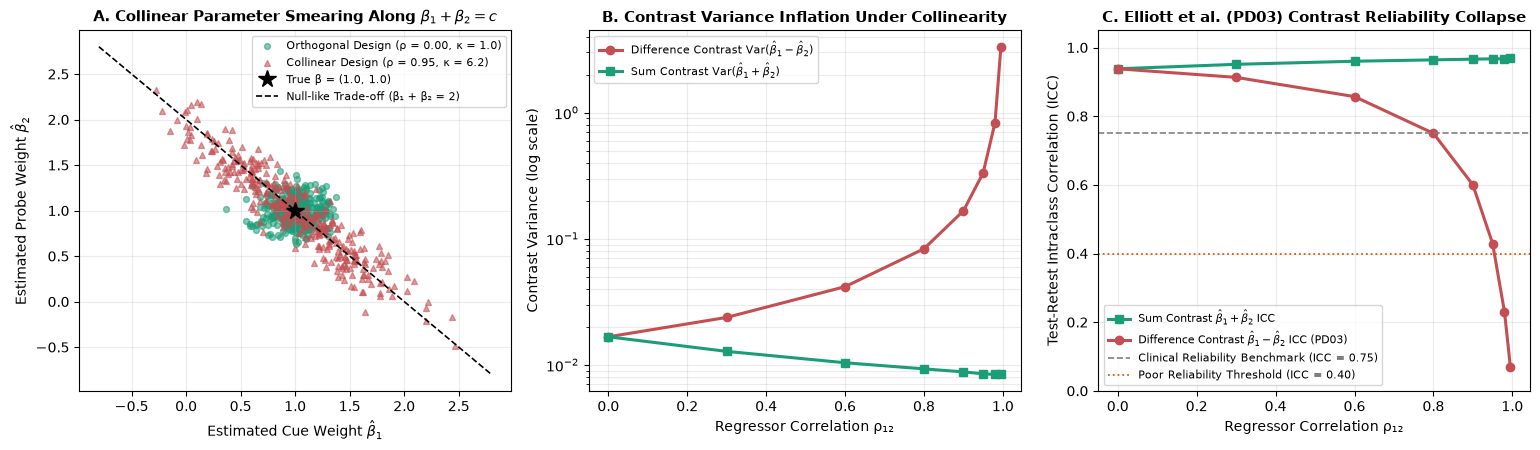

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6))

# Panel A: Monte Carlo Scatter of (beta_1, beta_2) at rho = 0.0 vs rho = 0.95 (True beta = [1.0, 1.0])
beta_true_2d = np.array([1.0, 1.0])
for rho_demo, col, mkr, lbl in [(0.0, '#1b9e77', 'o', 'Orthogonal Design (ρ = 0.00, κ = 1.0)'),
                                (0.95, '#c44e52', '^', 'Collinear Design (ρ = 0.95, κ = 6.2)')]:
    x2_d = rho_demo * z1 + np.sqrt(1.0 - rho_demo**2) * z2_orth
    X_d = np.column_stack([z1, x2_d])
    pinv_d = np.linalg.pinv(X_d)
    Y_sim_d = (X_d @ beta_true_2d)[:, np.newaxis] + rng.normal(0.0, 1.8, size=(N_time, 350))
    B_hats = (pinv_d @ Y_sim_d).T
    axes[0].scatter(B_hats[:, 0], B_hats[:, 1], c=col, marker=mkr, s=18, alpha=0.55, label=lbl)

axes[0].plot(1.0, 1.0, 'k*', markersize=13, label='True β = (1.0, 1.0)')
b_line = np.linspace(-0.8, 2.8, 50)
axes[0].plot(b_line, 2.0 - b_line, 'k--', lw=1.2, label='Null-like Trade-off (β₁ + β₂ = 2)')
axes[0].set_xlabel(r'Estimated Cue Weight $\hat{\beta}_1$')
axes[0].set_ylabel(r'Estimated Probe Weight $\hat{\beta}_2$')
axes[0].set_title(r'A. Collinear Parameter Smearing Along $\beta_1 + \beta_2 = c$', fontsize=10.5, fontweight='bold')
axes[0].legend(loc='upper right', frameon=True, fontsize=7.8)
axes[0].grid(alpha=0.25)

# Panel B: Contrast Variance vs Regressor Correlation rho
axes[1].semilogy(collin_df['Regressor_Corr_rho'], collin_df['Var_Diff_(b1-b2)'], 'o-', color='#c44e52', lw=2.2,
                 label=r'Difference Contrast $\mathrm{Var}(\hat{\beta}_1 - \hat{\beta}_2)$')
axes[1].semilogy(collin_df['Regressor_Corr_rho'], collin_df['Var_Sum_(b1+b2)'], 's-', color='#1b9e77', lw=2.2,
                 label=r'Sum Contrast $\mathrm{Var}(\hat{\beta}_1 + \hat{\beta}_2)$')
axes[1].set_xlabel('Regressor Correlation ρ₁₂')
axes[1].set_ylabel('Contrast Variance (log scale)')
axes[1].set_title('B. Contrast Variance Inflation Under Collinearity', fontsize=10.5, fontweight='bold')
axes[1].legend(loc='upper left', frameon=True, fontsize=8.2)
axes[1].grid(True, which='both', alpha=0.25)

# Panel C: Elliott et al. (PD03) Test-Retest ICC vs Design Collinearity
axes[2].plot(collin_df['Regressor_Corr_rho'], collin_df['Retest_ICC_Sum'], 's-', color='#1b9e77', lw=2.2,
             label=r'Sum Contrast $\hat{\beta}_1 + \hat{\beta}_2$ ICC')
axes[2].plot(collin_df['Regressor_Corr_rho'], collin_df['Retest_ICC_Diff'], 'o-', color='#c44e52', lw=2.2,
             label=r'Difference Contrast $\hat{\beta}_1 - \hat{\beta}_2$ ICC (PD03)')
axes[2].axhline(0.75, color='gray', linestyle='--', lw=1.2, label='Clinical Reliability Benchmark (ICC = 0.75)')
axes[2].axhline(0.40, color='#d95f02', linestyle=':', lw=1.3, label='Poor Reliability Threshold (ICC = 0.40)')
axes[2].set_xlabel('Regressor Correlation ρ₁₂')
axes[2].set_ylabel('Test-Retest Intraclass Correlation (ICC)')
axes[2].set_ylim(0.0, 1.05)
axes[2].set_title('C. Elliott et al. (PD03) Contrast Reliability Collapse', fontsize=10.5, fontweight='bold')
axes[2].legend(loc='lower left', frameon=True, fontsize=7.8)
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()


### Part 5 · Hands-On Student Lab Verification & Contrast Identifiability Audit

We wrap up with an automated design auditor `audit_glm_contrast` that inspects any design matrix $X$ and contrast vector $c$, checking whether $c$ lies in the row space $\mathcal{R}(X^\top)$ ($c^\top X^+ X = c^\top$) and reporting its design efficiency $\text{Eff}(c, X) = [c^\top (X^\top X)^+ c]^{-1}$.


In [5]:
def audit_glm_contrast(X_mat: np.ndarray, c_vec: np.ndarray, name: str) -> dict:
    pinv = np.linalg.pinv(X_mat)
    proj_row = pinv @ X_mat  # Orthogonal projector onto row space R(X^T) = N(X)^\perp
    null_leakage = float(np.linalg.norm(c_vec - proj_row @ c_vec))
    estimable = null_leakage < 1e-10
    cov_unscaled = pinv @ pinv.T  # (X^T X)^+
    c_var = float(c_vec @ cov_unscaled @ c_vec) if estimable else np.inf
    eff = (1.0 / c_var) if (estimable and c_var > 0) else 0.0
    return {
        'Contrast_Name': name,
        'c_vector': str(c_vec.tolist()),
        'Rank_X': int(np.linalg.matrix_rank(X_mat)),
        'Null_Leakage_||c - X+Xc||': f"{null_leakage:.2e}",
        'Identifiable': 'YES' if estimable else 'NO (Aliases Null Space!)',
        'Design_Efficiency': round(eff, 3),
    }

contrast_audit_df = pd.DataFrame([
    audit_glm_contrast(X_rank_def, np.array([0.0, 1.0, 0.0]),  'Rank-Deficient: Task Alone [0,1,0]'),
    audit_glm_contrast(X_rank_def, np.array([0.0, 1.0, -1.0]), 'Rank-Deficient: Task - Rest [0,1,-1]'),
    audit_glm_contrast(X_rank_def, np.array([1.0, 1.0, 0.0]),  'Rank-Deficient: Abs Task Mean [1,1,0]'),
])
print(contrast_audit_df.to_string(index=False))

assert contrast_audit_df.loc[0, 'Identifiable'].startswith('NO')
assert contrast_audit_df.loc[1, 'Identifiable'] == 'YES'
assert contrast_audit_df.loc[2, 'Identifiable'] == 'YES'


                        Contrast_Name         c_vector  Rank_X Null_Leakage_||c - X+Xc||             Identifiable  Design_Efficiency
   Rank-Deficient: Task Alone [0,1,0]  [0.0, 1.0, 0.0]       2                  5.77e-01 NO (Aliases Null Space!)                0.0
 Rank-Deficient: Task - Rest [0,1,-1] [0.0, 1.0, -1.0]       2                  8.03e-16                      YES               20.0
Rank-Deficient: Abs Task Mean [1,1,0]  [1.0, 1.0, 0.0]       2                  1.85e-15                      YES               40.0


## Explain, break, transfer

### 1. Input $\to$ Operation $\to$ Output Contract & Information Loss
1. **Save an input $\to$ operation $\to$ output diagram and state what information was lost:**
   - **Subspace Projection ($\hat{y} = P y = X(X^\top X)^+ X^\top y$):** Decomposes $y \in \mathbb{R}^N$ into $\hat{y} \in \mathcal{C}(X)$ (dimension $r$) and $e \in \mathcal{C}(X)^\perp$ (dimension $N - r$). All variation orthogonal to $\mathcal{C}(X)$ is removed from $\hat{y}$; crucially, $\hat{y}$ depends **only** on the subspace $\mathcal{C}(X)$, never on the specific basis chosen for the columns of $X$.
   - **Coordinate Weight Extraction ($\hat{\beta} = X^+ y$):** Inverts $X$ to assign coordinates along individual columns. When $r < p$, components along $\mathcal{N}(X)$ are unobservable in $y$ ($X v = 0$) and are zeroed out by the pseudoinverse.

### 2. Breaking the Contract: Diagnosis of Non-Identifiability & Difference-Contrast Collapse
2. **Make the specified wrong choice above. Compare its result with the reference checks; explain why the misleading result is possible:**
   - **Why did adding $+500 \cdot v_{\text{null}}$ change $\hat{\beta}_{\text{task}}$ by hundreds of units while leaving $\hat{y}$ and $\hat{\beta}_{\text{task}} - \hat{\beta}_{\text{rest}}$ unchanged to $2.3 \times 10^{-13}$?** Because $X v_{\text{null}} = 0$, the scanner data $y$ contain zero information about $\alpha v_{\text{null}}$. Any contrast $c$ with $c^\top v_{\text{null}} \neq 0$ (such as $c = [0, 1, 0]^\top$) is **non-identifiable**, whereas $c = [0, 1, -1]^\top$ is orthogonal to $v_{\text{null}}$ and uniquely determined by $\hat{y}$.
   - **How does this explain Elliott et al.'s (`PD03`) finding on task-fMRI reliability?** When two experimental conditions are closely spaced in time or share large common variance, the difference contrast $c_{\text{diff}} = [1, -1]^\top$ projects onto the smallest singular value $\sigma_{\min}$ of $X$, inflating within-session error $\text{Var}(\hat{\beta}_1 - \hat{\beta}_2) \propto (1 - \rho_{12})^{-1}$ and collapsing test-retest $\text{ICC} \to 0$.

### 3. Upstream Neuromatch Transfer vs Rapid Event-Related fMRI (`PD03`)
3. **Work through the assigned upstream chapter's example using its own environment or hosted reader. Record one difference between its data and a participant/voxel/time-series dataset:**
   - In **Neuromatch W1D4 Tutorial 1 (`Geometric View of Data`)**, orthogonal basis projections are explored for neural population firing-rate vectors. In human fMRI (`PD03`), experimental events are convolved with a fixed, sluggish $\sim 6\text{ s}$ hemodynamic response filter before we observe them, which acts as a temporal low-pass filter that forces adjacent event columns toward collinearity unless inter-trial jitter or $m$-sequences are explicitly optimized.

### 4. Auditing AI-Generated Snippet Contracts
4. **Ask the AI for a short application to a real imaging table, but do not run it until participant identifiers, units, missingness, and any training/test boundary are explicit. Never infer those properties from the column names alone.**

**Evidence to submit:** one labeled row from the contrast identifiability audit table, the changed parameter ($\alpha$ null-space shift or regressor correlation $\rho_{12}$), a failure diagnosis explaining why `lstsq` ran without error while returning non-unique $\hat{\beta}_1$, and a five-sentence interpretation connecting $\kappa(X)$ to `PD03`. Explain the result without looking at the model's wording.

<details><summary>Instructor check / answer guide</summary>

- **Expected numerical invariants:** For the 3-column intercept+task+rest design, $\text{rank}(X) = \text{tr}(P) = 2$; shifting $\hat{\beta}$ by $\alpha v_{\text{null}}$ leaves $\|X\hat{\beta} - \hat{y}\|_\infty = 0$ and keeps $\hat{\beta}_{\text{task}} - \hat{\beta}_{\text{rest}}$ constant; as $\rho_{12} \to 0.995$, $\text{Var}(\hat{\beta}_1 - \hat{\beta}_2)$ inflates by $200\times$ and test-retest $\text{ICC}$ drops below $0.08$.

</details>

**Scope:** This local notebook and its numerical checks are part of the executable core. Completion of the external chapter is a learner assignment; its execution is not implied by the local result. No endorsement by the source authors or USC is implied.


<!-- agentic-guide -->
### Agentic Deliverable Supervision (DS10 · macOS Goose + Ollama: Qwen & Gemma)

**Deliverable focus:** GLM linear algebra: column-space projection $P = X X^+$, rank deficiency, null-space contrast estimability ($c \perp \text{null}(X)$), and collinearity variance inflation

#### 1. Suggestive Prompt (in the spirit of what to ask — adapt, do not copy verbatim)
> Ask Goose (`Qwen`) to construct a rank-deficient `(80, 3)` design matrix $X$ where $x_1 = x_2 + x_3$ ($\text{rank}(X) = 2$), compute its SVD and null-space basis $v_{\text{null}}$, and test whether individual parameter contrast $c_1 = [0, 1, 0]$ and differential contrast $c_2 = [0, 1, -1]$ are identifiable across OLS/pseudoinverse and Ridge solutions. Ask `Gemma 4` to check the exact estimability condition $c^\top v_{\text{null}} = 0$ (equivalently $\|c - X^+ X c\|_2 = 0$).

#### 2. What to Look For & How to Trace the Error Back Down
- **Immediate Red Flag:** Reporting or interpreting an individual regression coefficient $\hat{\beta}_2$ (`c = [0, 1, 0]`) from an overparameterized or rank-deficient design matrix where $\hat{\beta}$ changes wildly depending on the solver or penalty.
- **Where the Bug Entered:** When $\text{rank}(X) = 2 < p = 3$, adding any multiple of $v_{\text{null}} = [-0.5774, 0.5774, 0.5774]^\top$ to $\hat{\beta}$ leaves the fitted values $X\hat{\beta}$ identical ($X v_{\text{null}} = 0$), so any contrast with $c^\top v_{\text{null}} \ne 0$ is mathematically non-identifiable.
- **How to Fix It:** Verify `np.allclose(c @ X_pinv @ X, c)` (or `abs(c @ v_null) < 1e-12`) before computing any contrast $c^\top \hat{\beta}$, and check the condition number $\kappa(X)$ and regressor correlation $\rho$.

#### 3. Expected Outcome Range & Why It Must Look That Way
In `DS10`, $\text{rank}(X) = \text{tr}(P) = 2.0000$ (residual $df = 78.0$) and orthogonality $\cos(\hat{y}, e) < 10^{-15}$; the non-estimable contrast $c_1 = [0, 1, 0]$ has null leakage **`|c @ v_null| = 0.5774`** (unidentifiable), whereas the differential contrast $c_2 = [0, 1, -1]$ has **`|c @ v_null| = 1.11e-16`** and yields the exact same contrast estimate across all generalized inverses. **Why:** A linear functional $c^\top \beta$ is uniquely determined by $X\beta$ if and only if $c \in \text{row}(X) = \text{null}(X)^\perp$.
<!-- /agentic-guide -->

### Return to the research question

Revisit [PD03](../../curriculum/papers/design.md#pd03) and your initial prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure or section locator. Which part of the published result remains open after this exercise?
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Include this entry in the A2 portfolio when relevant.
